# Section 2 — Exemple historique simulé

Dans cette section, on étudie le comportement du LASSO sur un exemple simulé inspiré de Tibshirani (1996).

On utilise la convention suivante :

$$
\widehat{\beta}_{\lambda}
\in
\arg\min_{\beta\in\mathbb{R}^d}
\left\{
\frac{1}{2n}\|Y-X\beta\|_2^2
+
\frac{\lambda}{2n}\|\beta\|_1
\right\}.
$$

Comme `sklearn.linear_model.Lasso` minimise

$$
\frac{1}{2n}\|Y-X\beta\|_2^2+\alpha\|\beta\|_1,
$$

on utilisera donc

$$
\alpha=\frac{\lambda}{2n}.
$$

In [6]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import Lasso
from sklearn.model_selection import KFold

# Grille de valeurs demandée dans l'énoncé
lam_grid = np.arange(0.01, 2.01, 0.01)

# Pour rendre la simulation reproductible
np.random.seed(42)

def lasso_fit(X_train, Y_train, lam):
    n_train = len(Y_train)
    alpha = lam / (2 * n_train)

    model = Lasso(
        alpha=alpha,
        fit_intercept=False,
        max_iter=100000,
        tol=1e-10
    )
    model.fit(X_train, Y_train)
    return model.coef_

def l0_norm(beta, eps=1e-8):
    return np.sum(np.abs(beta) > eps)

## Question 1 — Simulation du modèle

On simule \(n=20\) observations en dimension \(d=8\).

Pour chaque observation, on génère

$$
X_i\sim \mathcal{N}(0,I_8),
\qquad
\varepsilon_i\sim \mathcal{N}(0,1),
$$

puis

$$
Y_i=X_i^\top\beta^\star+\varepsilon_i,
$$

avec

$$
\beta^\star=(5,3,0,0,1.5,0,0,0)^\top.
$$

Le vrai support est donc

$$
S^\star=\{1,2,5\}.
$$

Autrement dit, seules trois variables ont un effet réel dans le modèle simulé. Les autres variables sont présentes dans les données, mais leur coefficient vrai est nul.

In [7]:
n_samples = 20
dim = 8

X = np.random.standard_normal((n_samples, dim))

beta_star = np.array([5, 3, 0, 0, 1.5, 0, 0, 0])

eps = np.random.standard_normal(n_samples)

Y = X @ beta_star + eps

print("Shape de X :", X.shape)
print("Shape de Y :", Y.shape)
print("beta_star :", beta_star)
print("Nombre de coefficients non nuls dans beta_star :", np.sum(beta_star != 0))

Shape de X : (20, 8)
Shape de Y : (20,)
beta_star : [5.  3.  0.  0.  1.5 0.  0.  0. ]
Nombre de coefficients non nuls dans beta_star : 3


## Question 2 — Erreur prédictive in-sample

Pour chaque valeur de $\lambda$, on calcule l'estimateur LASSO $\widehat{\beta}_{\lambda}$, puis on trace la fonction :

$$
\lambda
\longmapsto
\|X(\widehat{\beta}_{\lambda}-\beta^\star)\|_2^2.
$$

Cette quantité mesure l'écart prédictif, sur l'échantillon simulé, entre le modèle estimé et le vrai modèle linéaire.

Elle est calculable ici uniquement parce que l'on connaît $\beta^\star$. En pratique, ce vecteur est inconnu. Ce critère joue donc ici le rôle d'un critère oracle.

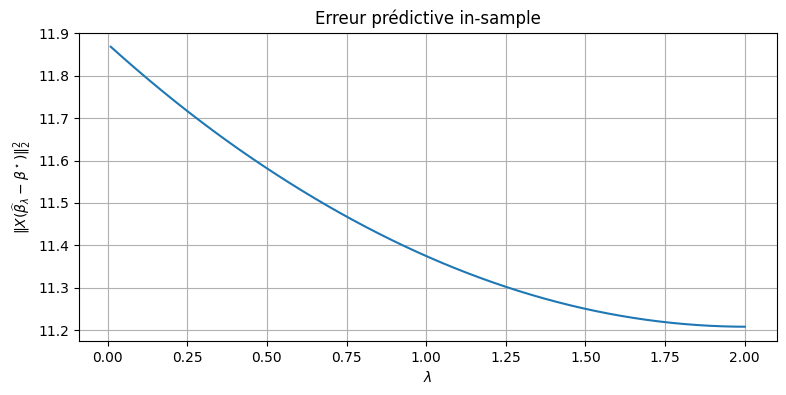

lambda optimal in-sample = 2.00
erreur minimale in-sample = 11.2077


In [8]:
in_sample_errors = []

for lam in lam_grid:
    beta_hat = lasso_fit(X, Y, lam)
    error = np.linalg.norm(X @ (beta_hat - beta_star))**2
    in_sample_errors.append(error)

in_sample_errors = np.array(in_sample_errors)

lambda_in_sample = lam_grid[np.argmin(in_sample_errors)]

plt.figure(figsize=(9, 4))
plt.plot(lam_grid, in_sample_errors)
plt.xlabel(r"$\lambda$")
plt.ylabel(r"$\|X(\widehat{\beta}_{\lambda}-\beta^\star)\|_2^2$")
plt.title("Erreur prédictive in-sample")
plt.grid(True)
plt.savefig("section2_q2_in_sample_error.png", dpi=300, bbox_inches="tight")
plt.show()

print(f"lambda optimal in-sample = {lambda_in_sample:.2f}")
print(f"erreur minimale in-sample = {np.min(in_sample_errors):.4f}")

## Question 3 — Sélection de $\lambda$ par validation croisée

Dans la question précédente, le choix de $\lambda$ utilisait la connaissance de $\beta^\star$.

Cette méthode est donc impossible en pratique, puisque $\beta^\star$ est précisément inconnu.

On choisit alors $\lambda$ par validation croisée à cinq plis.

Pour chaque valeur de $\lambda$, les données sont découpées en cinq sous-échantillons. Le modèle est entraîné sur quatre plis, puis évalué sur le pli restant. On répète l'opération cinq fois, de sorte que chaque pli serve une fois d'ensemble de validation.

L'erreur de validation croisée associée à $\lambda$ est ensuite obtenue en moyennant les cinq erreurs de validation. Le paramètre sélectionné est celui qui minimise cette erreur moyenne.

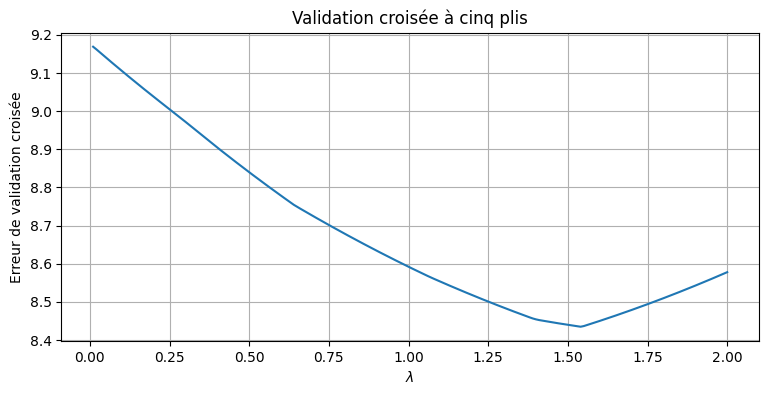

lambda optimal par validation croisée = 1.54
erreur minimale de validation croisée = 8.4348
lambda optimal in-sample = 2.00


In [9]:
kf = KFold(n_splits=5, shuffle=True, random_state=0)

cv_errors = []

for lam in lam_grid:
    fold_errors = []

    for train_idx, val_idx in kf.split(X):
        X_train, X_val = X[train_idx], X[val_idx]
        Y_train, Y_val = Y[train_idx], Y[val_idx]

        beta_hat = lasso_fit(X_train, Y_train, lam)

        val_error = np.linalg.norm(Y_val - X_val @ beta_hat)**2
        fold_errors.append(val_error)

    cv_errors.append(np.mean(fold_errors))

cv_errors = np.array(cv_errors)

lambda_cv = lam_grid[np.argmin(cv_errors)]

plt.figure(figsize=(9, 4))
plt.plot(lam_grid, cv_errors)
plt.xlabel(r"$\lambda$")
plt.ylabel("Erreur de validation croisée")
plt.title("Validation croisée à cinq plis")
plt.grid(True)
plt.savefig("section2_q3_cross_validation.png", dpi=300, bbox_inches="tight")
plt.show()

print(f"lambda optimal par validation croisée = {lambda_cv:.2f}")
print(f"erreur minimale de validation croisée = {np.min(cv_errors):.4f}")
print(f"lambda optimal in-sample = {lambda_in_sample:.2f}")

## Question 4 — Nombre de coefficients non nuls

On trace maintenant la fonction :

$$
\lambda
\longmapsto
\|\widehat{\beta}_{\lambda}\|_0,
$$

où $\|\widehat{\beta}_{\lambda}\|_0$ désigne le nombre de coefficients non nuls de l'estimateur LASSO.

Comme :

$$
\beta^\star=(5,3,0,0,1.5,0,0,0)^\top,
$$

le vrai modèle contient exactement trois coefficients non nuls.

Cette question permet donc de comparer le choix de $\lambda$ obtenu par prédiction avec la parcimonie du modèle sélectionné. En particulier, on veut voir si le $\lambda$ optimal pour la prédiction conduit aussi à un modèle avec le bon nombre de variables actives.

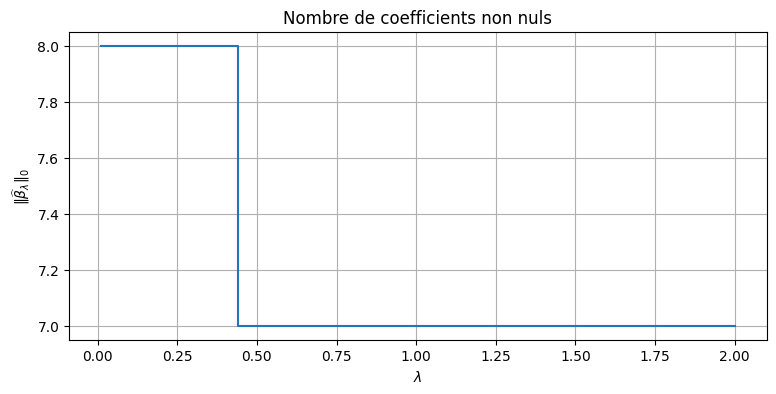

lambda optimal in-sample = 2.00
Nombre de coefficients non nuls pour lambda in-sample : 7
lambda optimal par validation croisée = 1.54
Nombre de coefficients non nuls pour lambda CV : 7
Aucune valeur de lambda dans la grille ne donne exactement 3 coefficients non nuls.


In [10]:
l0_values = []

for lam in lam_grid:
    beta_hat = lasso_fit(X, Y, lam)
    l0_values.append(l0_norm(beta_hat))

l0_values = np.array(l0_values)

plt.figure(figsize=(9, 4))
plt.step(lam_grid, l0_values, where="post")
plt.xlabel(r"$\lambda$")
plt.ylabel(r"$\|\widehat{\beta}_{\lambda}\|_0$")
plt.title("Nombre de coefficients non nuls")
plt.grid(True)
plt.savefig("section2_q4_nonzero_coefficients.png", dpi=300, bbox_inches="tight")
plt.show()

idx_in_sample = np.argmin(in_sample_errors)
idx_cv = np.argmin(cv_errors)

print(f"lambda optimal in-sample = {lambda_in_sample:.2f}")
print("Nombre de coefficients non nuls pour lambda in-sample :",
      l0_values[idx_in_sample])

print(f"lambda optimal par validation croisée = {lambda_cv:.2f}")
print("Nombre de coefficients non nuls pour lambda CV :",
      l0_values[idx_cv])

indices_three = np.where(l0_values == 3)[0]

if len(indices_three) > 0:
    lambda_min_three = lam_grid[indices_three[0]]
    lambda_max_three = lam_grid[indices_three[-1]]
    print(f"Valeurs de lambda pour lesquelles ||beta_hat||_0 = 3 : de {lambda_min_three:.2f} à {lambda_max_three:.2f}")
else:
    print("Aucune valeur de lambda dans la grille ne donne exactement 3 coefficients non nuls.")

In [11]:
# Résumé des résultats de la section 2

print("Résumé Section 2")
print("----------------")
print(f"lambda optimal in-sample : {lambda_in_sample:.2f}")
print(f"lambda optimal par validation croisée : {lambda_cv:.2f}")
print(f"Nombre de coefficients non nuls pour lambda in-sample : {l0_values[idx_in_sample]}")
print(f"Nombre de coefficients non nuls pour lambda CV : {l0_values[idx_cv]}")
print(f"Nombre de coefficients non nuls dans beta_star : {np.sum(beta_star != 0)}")

if len(indices_three) > 0:
    print(f"Intervalle de lambda donnant exactement 3 coefficients non nuls : [{lambda_min_three:.2f}, {lambda_max_three:.2f}]")
else:
    print("Aucun lambda de la grille ne donne exactement 3 coefficients non nuls.")

Résumé Section 2
----------------
lambda optimal in-sample : 2.00
lambda optimal par validation croisée : 1.54
Nombre de coefficients non nuls pour lambda in-sample : 7
Nombre de coefficients non nuls pour lambda CV : 7
Nombre de coefficients non nuls dans beta_star : 3
Aucun lambda de la grille ne donne exactement 3 coefficients non nuls.


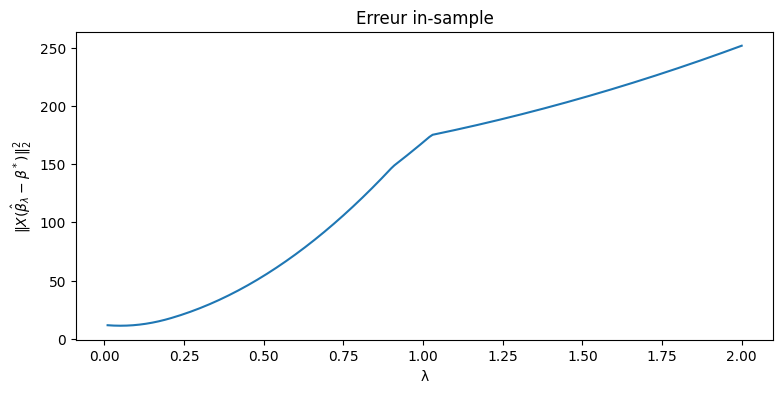

λ optimal (in-sample) = 0.05


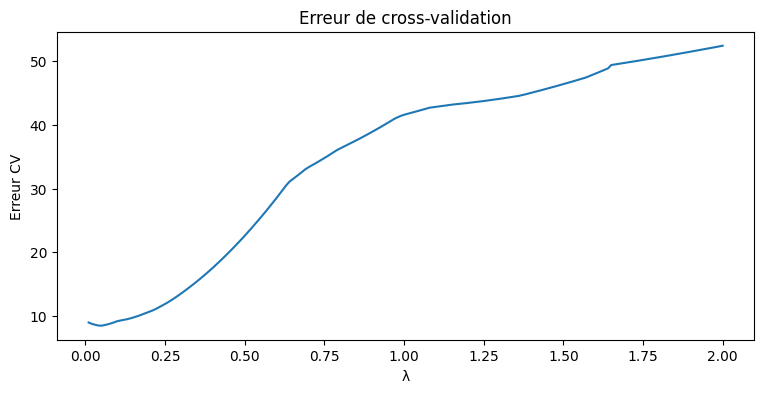

λ optimal (Cross-Validation) = 0.05
λ optimal (in-sample) = 0.05


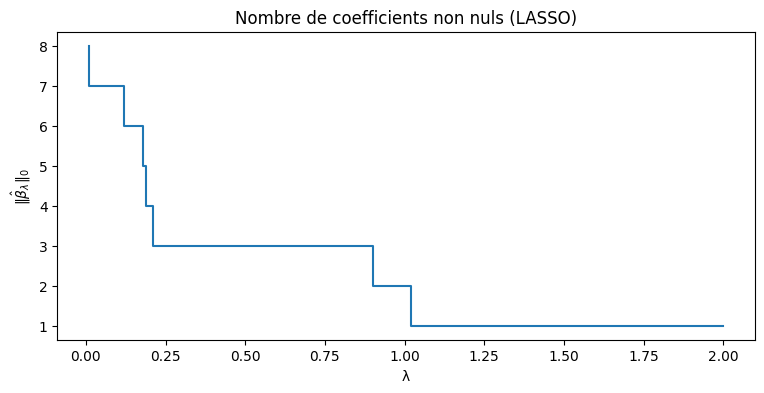

In [12]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import Lasso
from sklearn.model_selection import KFold

# Question 1
np.random.seed(42)
n_samples = 20
dim = 8
X = np.random.standard_normal((n_samples, dim))
beta_star = np.array([5, 3, 0, 0, 1.5, 0, 0, 0])
eps = np.random.standard_normal(n_samples)
Y = X @ beta_star + eps

lam_grid = np.arange(0.01, 2.01, 0.01)

# Question 2
def lasso_fit(X, Y, lam):
    # alpha = lam / (2*n) dans sklearn (convention)
    #model = Lasso(alpha=lam / (2 * len(Y)), fit_intercept=False, max_iter=10000)
    model = Lasso(alpha=lam, fit_intercept=False, max_iter=10000)
    model.fit(X, Y)
    return model.coef_

err_lam = np.array([
    np.linalg.norm(X @ (lasso_fit(X, Y, lam) - beta_star))**2
    for lam in lam_grid
])

plt.figure(figsize=(9, 4))
plt.plot(lam_grid, err_lam)
plt.xlabel("λ")
plt.ylabel(r"$\|X(\hat{\beta}_\lambda - \beta^*)\|_2^2$")
plt.title("Erreur in-sample")
plt.show()

lambda_opt = lam_grid[np.argmin(err_lam)]
print(f"λ optimal (in-sample) = {lambda_opt:.2f}")

# Question 3
kf = KFold(n_splits=5, shuffle=True, random_state=0)
cv_errors = []

for lam in lam_grid:
    err = 0
    for train_idx, val_idx in kf.split(X):
        X_train, X_val = X[train_idx], X[val_idx]
        Y_train, Y_val = Y[train_idx], Y[val_idx]

        beta = lasso_fit(X_train, Y_train, lam)
        err += np.linalg.norm(X_val @ beta - Y_val)**2
    cv_errors.append(err / kf.get_n_splits())

plt.figure(figsize=(9, 4))
plt.plot(lam_grid, cv_errors)
plt.xlabel("λ")
plt.ylabel("Erreur CV")
plt.title("Erreur de cross-validation")
plt.show()

lambda_cv = lam_grid[np.argmin(cv_errors)]
print(f"λ optimal (Cross-Validation) = {lambda_cv:.2f}")
print(f"λ optimal (in-sample) = {lambda_opt:.2f}")

# Question 4
def l0_norm(beta, eps=1e-8):
    return np.sum(np.abs(beta) > eps)

beta_l0 = np.array([l0_norm(lasso_fit(X, Y, lam)) for lam in lam_grid])

plt.figure(figsize=(9, 4))
plt.step(lam_grid, beta_l0)
plt.xlabel("λ")
plt.ylabel(r"$\|\hat{\beta}_\lambda\|_0$")
plt.title("Nombre de coefficients non nuls (LASSO)")
plt.show()

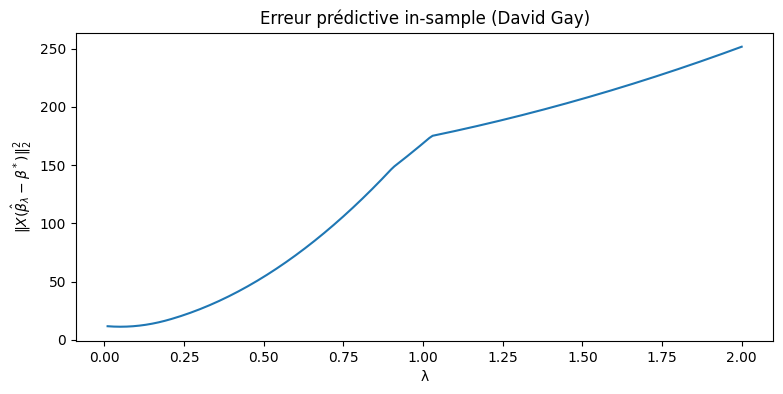

λ optimal (in-sample) = 0.05


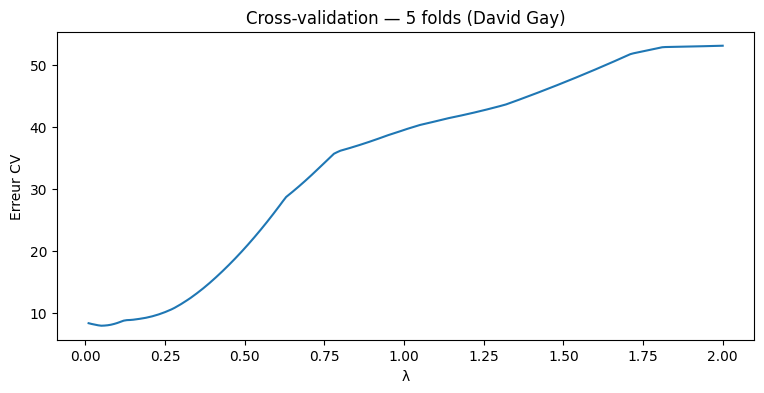

λ optimal (CV) = 0.05
λ optimal (in-sample) = 0.05


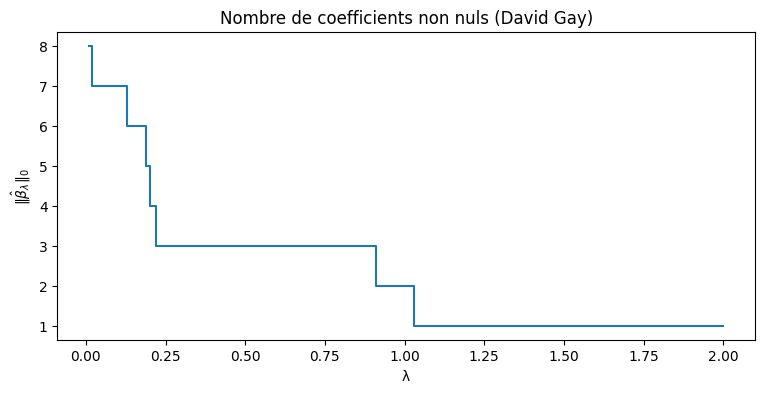

In [13]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import minimize


np.random.seed(42)
n_samples = 20
dim = 8
X = np.random.standard_normal((n_samples, dim))
beta_star = np.array([5, 3, 0, 0, 1.5, 0, 0, 0])
eps = np.random.standard_normal(n_samples)
Y = X @ beta_star + eps

lam_grid = np.arange(0.01, 2.01, 0.01)

# Algorithme de David Gay : β_j = β_j^+ - β_j^-, β_j^+,β_j^- ≥ 0
# z = [β^+_1,...,β^+_p, β^-_1,...,β^-_p]  taille 2p
# L1 se linéarise : ||β||_1 = Σ(β_j^+ + β_j^-)

def lasso_gay(X, Y, lam):
    n, p = X.shape

    # Objectif : (1/2n)||Y - X(β^+ - β^-)||² + λ * Σ(β_j^+ + β_j^-)
    def objective(z):
        beta_plus  = z[:p]
        beta_minus = z[p:]
        beta = beta_plus - beta_minus
        return (1 / (2 * n)) * np.linalg.norm(Y - X @ beta)**2 \
               + lam * np.sum(beta_plus + beta_minus)

    def gradient(z):
        beta_plus  = z[:p]
        beta_minus = z[p:]
        beta = beta_plus - beta_minus
        residual = Y - X @ beta
        grad_common = -(1 / n) * X.T @ residual   # = ∂(moindres carrés)/∂β
        # ∂/∂β^+ = grad_common + λ
        # ∂/∂β^- = -grad_common + λ
        return np.concatenate([grad_common + lam, -grad_common + lam])

    # Contraintes : β_j^+ ≥ 0 et β_j^- ≥ 0  (2p bornes)
    bounds = [(0, None)] * (2 * p)

    z0 = np.zeros(2 * p)
    result = minimize(objective, z0, jac=gradient,
                      method="SLSQP", bounds=bounds,
                      options={"ftol": 1e-10, "maxiter": 10000})

    beta_plus  = result.x[:p]
    beta_minus = result.x[p:]
    return beta_plus - beta_minus

# Question 2
err_lam = []

for lam in lam_grid:
    beta_hat = lasso_gay(X, Y, lam)
    err_lam.append(np.linalg.norm(X @ (beta_hat - beta_star))**2)

err_lam    = np.array(err_lam)
lambda_opt = lam_grid[np.argmin(err_lam)]

plt.figure(figsize=(9, 4))
plt.plot(lam_grid, err_lam)
plt.xlabel("λ")
plt.ylabel(r"$\|X(\hat{\beta}_\lambda - \beta^*)\|_2^2$")
plt.title("Erreur prédictive in-sample (David Gay)")
plt.show()

print(f"λ optimal (in-sample) = {lambda_opt:.2f}")

# Question 3
n_folds = 5
m = n_samples // n_folds

sigma = np.random.permutation(n_samples)
X_tilde = X[sigma]
Y_tilde = Y[sigma]

cv_errors = []

for lam in lam_grid:
    err_lambda = []

    for i in range(n_folds):
        val_idx   = np.arange(i * m, (i + 1) * m)
        train_idx = np.concatenate([np.arange(k * m, (k + 1) * m)
                                    for k in range(n_folds) if k != i])

        X_train, X_val = X_tilde[train_idx], X_tilde[val_idx]
        Y_train, Y_val = Y_tilde[train_idx], Y_tilde[val_idx]

        beta_hat = lasso_gay(X_train, Y_train, lam)
        err_lambda.append(np.linalg.norm(X_val @ beta_hat - Y_val)**2)

    cv_errors.append(np.mean(err_lambda))

cv_errors  = np.array(cv_errors)
lambda_cv  = lam_grid[np.argmin(cv_errors)]

plt.figure(figsize=(9, 4))
plt.plot(lam_grid, cv_errors)
plt.xlabel("λ"); plt.ylabel("Erreur CV")
plt.title("Cross-validation — 5 folds (David Gay)")
plt.show()

print(f"λ optimal (CV) = {lambda_cv:.2f}")
print(f"λ optimal (in-sample) = {lambda_opt:.2f}")

# Question 4
beta_l0 = []

for lam in lam_grid:
    beta_hat = lasso_gay(X, Y, lam)
    beta_l0.append(np.sum(np.abs(beta_hat) > 1e-8))

beta_l0 = np.array(beta_l0)

plt.figure(figsize=(9, 4))
plt.step(lam_grid, beta_l0, where='post')
plt.xlabel("λ"); plt.ylabel(r"$\|\hat{\beta}_\lambda\|_0$")
plt.title("Nombre de coefficients non nuls (David Gay)")
plt.show()